<a href="https://colab.research.google.com/github/vdthang221/PforAI/blob/main/Copy_of_Group_BTTH_PAIDS_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bài Tập Lớn: Khai Phá Dữ Liệu & Trí Tuệ Nhân Tạo
## Dự Đoán Bệnh Tiểu Đường Sử Dụng Classic Machine Learning

**Mục tiêu:** Xây dựng pipeline Machine Learning hoàn chỉnh để dự đoán nguy cơ mắc bệnh tiểu đường dựa trên các chỉ số sức khỏe.

**Bộ dữ liệu:** BRFSS 2015 Diabetes Health Indicators (253,680 mẫu)

---

## 1. Cài Đặt & Import Thư Viện

In [1]:
# Cài đặt các thư viện cần thiết
!pip install pandas numpy scikit-learn mlxtend matplotlib seaborn imbalanced-learn --quiet

In [2]:
# =====================================================================
# IMPORT THƯ VIỆN
# =====================================================================

# Data manipulation
import pandas as pd
import numpy as np
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import userdata

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

# Machine Learning Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Association Rule Learning
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Tất cả thư viện đã được import thành công!")

Tất cả thư viện đã được import thành công!


---
## 2. Tổng Quan Vấn Đề & Khảo Sát Phương Pháp

### 2.1 Giới thiệu bài toán

**Bệnh tiểu đường (Diabetes)** là một trong những bệnh mãn tính phổ biến nhất trên thế giới, ảnh hưởng đến hàng trăm triệu người. Việc phát hiện sớm nguy cơ mắc bệnh tiểu đường có ý nghĩa quan trọng trong:
- Phòng ngừa và điều trị kịp thời
- Giảm chi phí y tế
- Nâng cao chất lượng cuộc sống

### 2.2 Các phương pháp Classic Machine Learning thường dùng

| Phương pháp | Ưu điểm | Nhược điểm |
|-------------|---------|------------|
| **Decision Tree** | Dễ giải thích, xử lý tốt dữ liệu phi tuyến | Dễ overfit, không ổn định |
| **Logistic Regression** | Nhanh, cho xác suất dự đoán | Giả định quan hệ tuyến tính |
| **Random Forest** | Robust, ít overfit | Khó giải thích, chậm hơn |
| **SVM** | Tốt cho high-dimensional data | Chậm với dataset lớn |

### 2.3 Mô tả bộ dữ liệu

Bộ dữ liệu BRFSS 2015 bao gồm 21 đặc trưng về sức khỏe và lối sống:

| Feature | Mô tả | Kiểu |
|---------|-------|------|
| Diabetes_binary | Biến mục tiêu (0: Không, 1: Có) | Binary |
| HighBP | Huyết áp cao | Binary |
| HighChol | Cholesterol cao | Binary |
| CholCheck | Kiểm tra cholesterol trong 5 năm | Binary |
| BMI | Chỉ số khối cơ thể | Numeric |
| Smoker | Hút thuốc | Binary |
| Stroke | Đột quỵ | Binary |
| HeartDiseaseorAttack | Bệnh tim/đau tim | Binary |
| PhysActivity | Hoạt động thể chất | Binary |
| Fruits | Ăn trái cây hàng ngày | Binary |
| Veggies | Ăn rau hàng ngày | Binary |
| HvyAlcoholConsump | Uống rượu nhiều | Binary |
| AnyHealthcare | Có bảo hiểm y tế | Binary |
| NoDocbcCost | Không đủ tiền khám bác sĩ | Binary |
| GenHlth | Sức khỏe tổng quát (1-5) | Ordinal |
| MentHlth | Số ngày sức khỏe tâm thần kém | Numeric |
| PhysHlth | Số ngày sức khỏe thể chất kém | Numeric |
| DiffWalk | Khó khăn khi đi bộ | Binary |
| Sex | Giới tính | Binary |
| Age | Nhóm tuổi (1-13) | Ordinal |
| Education | Trình độ học vấn (1-6) | Ordinal |
| Income | Thu nhập (1-8) | Ordinal |

---
## 3. Tải Dữ Liệu & Khám Phá Dữ Liệu (EDA)

In [3]:
# =====================================================================
# TẢI DỮ LIỆU
# =====================================================================
!kaggle datasets download -d alexteboul/diabetes-health-indicators-dataset
!unzip "diabetes-health-indicators-dataset.zip"
# Đọc file CSV
DATA_PATH = '/content/diabetes_binary_5050split_health_indicators_BRFSS2015.csv'
df = pd.read_csv(DATA_PATH)
print(f"Kích thước dữ liệu: {df.shape[0]:,} dòng x {df.shape[1]} cột")
print("="*60)

Dataset URL: https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset
License(s): CC0-1.0
100% 6.03M/6.03M [00:00<00:00, 37.0MB/s]

Archive:  diabetes-health-indicators-dataset.zip
  inflating: diabetes_012_health_indicators_BRFSS2015.csv  
  inflating: diabetes_binary_5050split_health_indicators_BRFSS2015.csv  
  inflating: diabetes_binary_health_indicators_BRFSS2015.csv  
Kích thước dữ liệu: 70,692 dòng x 22 cột


In [4]:
# Xem 5 dòng đầu tiên
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [5]:
# =====================================================================
# THÔNG TIN TỔNG QUAN
# =====================================================================

print("THÔNG TIN DỮ LIỆU:")
print("="*60)
df.info()

THÔNG TIN DỮ LIỆU:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  

In [6]:
# Thống kê mô tả
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,70692.0,0.500000,0.500004,0.0,0.0,0.5,1.0,1.0
HighBP,70692.0,0.563458,0.495960,0.0,0.0,1.0,1.0,1.0
HighChol,70692.0,0.525703,0.499342,0.0,0.0,1.0,1.0,1.0
CholCheck,70692.0,0.975259,0.155336,0.0,1.0,1.0,1.0,1.0
BMI,70692.0,29.856985,7.113954,12.0,25.0,29.0,33.0,98.0
Smoker,70692.0,0.475273,0.499392,0.0,0.0,0.0,1.0,1.0
Stroke,70692.0,0.062171,0.241468,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,70692.0,0.147810,0.354914,0.0,0.0,0.0,0.0,1.0
PhysActivity,70692.0,0.703036,0.456924,0.0,0.0,1.0,1.0,1.0
Fruits,70692.0,0.611795,0.487345,0.0,0.0,1.0,1.0,1.0


In [7]:
# =====================================================================
# KIỂM TRA GIÁ TRỊ THIẾU (MISSING VALUES)
# =====================================================================

missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percent (%)': missing_percent
})

print("KIỂM TRA GIÁ TRỊ THIẾU:")
print("="*60)
print(missing_df[missing_df['Missing Count'] > 0])

if missing_values.sum() == 0:
    print("\nKhông có giá trị thiếu trong dữ liệu!")

KIỂM TRA GIÁ TRỊ THIẾU:
Empty DataFrame
Columns: [Missing Count, Missing Percent (%)]
Index: []

Không có giá trị thiếu trong dữ liệu!


In [8]:
# =====================================================================
# PHÂN BỐ BIẾN MỤC TIÊU
# =====================================================================

print("PHÂN BỐ BIẾN MỤC TIÊU (Diabetes_binary):")
print("="*60)
target_dist = df['Diabetes_binary'].value_counts()
target_percent = df['Diabetes_binary'].value_counts(normalize=True) * 100

print(f"Không tiểu đường (0): {target_dist[0.0]:,} ({target_percent[0.0]:.2f}%)")
print(f"Tiểu đường (1): {target_dist[1.0]:,} ({target_percent[1.0]:.2f}%)")
print("\nDữ liệu đã được cân bằng (50/50 split)")

PHÂN BỐ BIẾN MỤC TIÊU (Diabetes_binary):
Không tiểu đường (0): 35,346 (50.00%)
Tiểu đường (1): 35,346 (50.00%)

Dữ liệu đã được cân bằng (50/50 split)


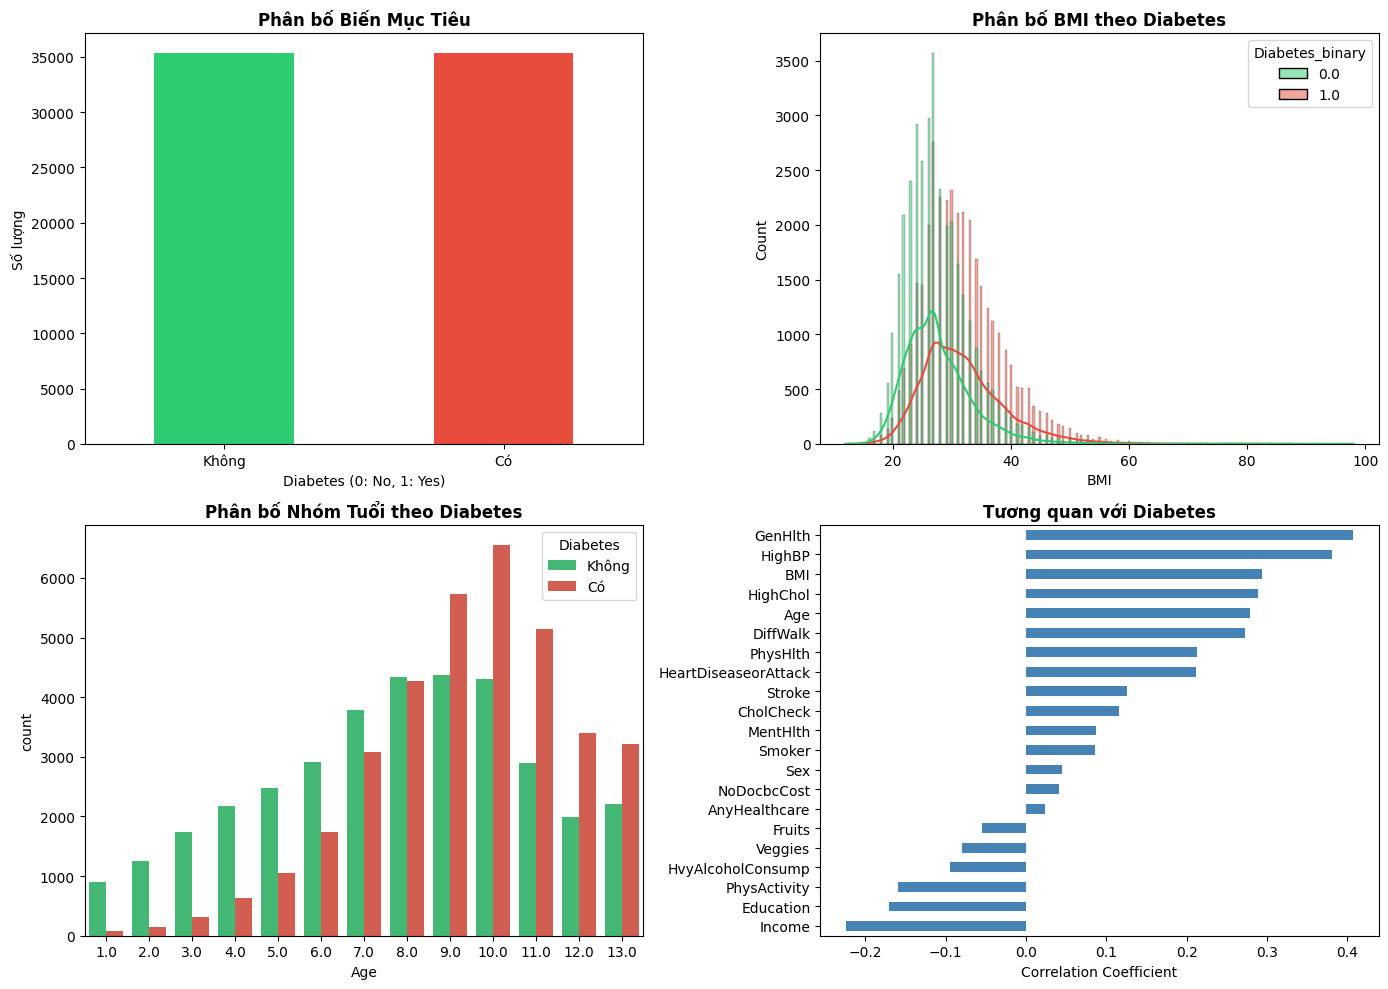


Đã lưu biểu đồ vào file 'eda_overview.png'


In [9]:
# =====================================================================
# TRỰC QUAN HÓA PHÂN BỐ DỮ LIỆU
# =====================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Phân bố biến mục tiêu
ax1 = axes[0, 0]
colors = ['#2ecc71', '#e74c3c']
df['Diabetes_binary'].value_counts().plot(kind='bar', ax=ax1, color=colors)
ax1.set_title('Phân bố Biến Mục Tiêu', fontsize=12, fontweight='bold')
ax1.set_xlabel('Diabetes (0: No, 1: Yes)')
ax1.set_ylabel('Số lượng')
ax1.set_xticklabels(['Không', 'Có'], rotation=0)

# 2. Phân bố BMI
ax2 = axes[0, 1]
sns.histplot(data=df, x='BMI', hue='Diabetes_binary', kde=True, ax=ax2, palette=colors)
ax2.set_title('Phân bố BMI theo Diabetes', fontsize=12, fontweight='bold')

# 3. Phân bố Tuổi
ax3 = axes[1, 0]
sns.countplot(data=df, x='Age', hue='Diabetes_binary', ax=ax3, palette=colors)
ax3.set_title('Phân bố Nhóm Tuổi theo Diabetes', fontsize=12, fontweight='bold')
ax3.legend(title='Diabetes', labels=['Không', 'Có'])

# 4. Correlation với biến mục tiêu
ax4 = axes[1, 1]
correlations = df.corr()['Diabetes_binary'].drop('Diabetes_binary').sort_values()
correlations.plot(kind='barh', ax=ax4, color='steelblue')
ax4.set_title('Tương quan với Diabetes', fontsize=12, fontweight='bold')
ax4.set_xlabel('Correlation Coefficient')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nĐã lưu biểu đồ vào file 'eda_overview.png'")

---
## 4. Tiền Xử Lý Dữ Liệu & Feature Engineering

- Làm sạch và chuẩn hóa dữ liệu
- Loại bỏ hoặc xử lý các giá trị không hợp lệ
- Tạo ra các đặc trưng có ý nghĩa hơn cho mô hình
---

### Quy trình thực hiện

Quy trình gồm các bước chính:

1. Khám phá dữ liệu: kiểm tra cấu trúc, kiểu dữ liệu và giá trị thiếu  
2. Xử lý missing values: loại bỏ hoặc thay thế bằng giá trị phù hợp  
3. Xử lý outliers: phát hiện và xử lý các giá trị bất thường  
4. Chuẩn hóa dữ liệu: scaling và encoding nếu cần  
5. Feature engineering: tạo và chọn lọc các feature quan trọng  

---

### Kết luận

Đây là bước nền tảng của toàn bộ pipeline. Chất lượng dữ liệu sau xử lý ảnh hưởng trực tiếp đến hiệu suất của mô hình.

In [10]:
# =====================================================================
# TIỀN XỬ LÝ DỮ LIỆU
# =====================================================================

# Tạo bản sao để xử lý
df_processed = df.copy()

# Xử lý giá trị thiếu bằng cách loại bỏ các dòng có NaN
df_processed.dropna(inplace=True)
print("Đã xử lý giá trị thiếu bằng cách loại bỏ các dòng có NaN.")

# Chuyển đổi kiểu dữ liệu
# Các cột binary nên là int
binary_cols = ['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'Smoker',
               'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits',
               'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost',
               'DiffWalk', 'Sex']

for col in binary_cols:
    df_processed[col] = df_processed[col].astype(int)

print("Đã chuyển đổi kiểu dữ liệu cho các cột binary")

Đã xử lý giá trị thiếu bằng cách loại bỏ các dòng có NaN.
Đã chuyển đổi kiểu dữ liệu cho các cột binary


### FEATURE ENGINEERING - TẠO ĐẶC TRƯNG MỚI

Dữ liệu ban đầu không phải lúc nào cũng thể hiện rõ mối quan hệ cần thiết để mô hình học tốt. Việc tạo thêm đặc trưng mới giúp làm nổi bật các pattern tiềm ẩn và cải thiện khả năng dự đoán.

---

### Cách thực hiện

Trong bước này, các feature mới được tạo ra bằng cách:
- Kết hợp các feature hiện có
- Biến đổi dữ liệu (log, normalization, binning, ...)
- Trích xuất thông tin quan trọng từ dữ liệu gốc

Mục tiêu là tạo ra các đặc trưng có ý nghĩa hơn và phù hợp hơn với bài toán.

---

### Kết luận

Feature engineering có thể cải thiện đáng kể hiệu suất mô hình. Một tập feature tốt thường quan trọng hơn việc chọn mô hình phức tạp.

In [11]:
# =====================================================================
# FEATURE ENGINEERING - TẠO ĐẶC TRƯNG MỚI
# =====================================================================

# 1. BMI Categories (Phân loại BMI)
def categorize_bmi(bmi):
    """Phân loại BMI theo tiêu chuẩn WHO"""
    if bmi < 18.5:
        return 0  # Underweight
    elif bmi < 25:
        return 1  # Normal
    elif bmi < 30:
        return 2  # Overweight
    else:
        return 3  # Obese

df_processed['BMI_Category'] = df_processed['BMI'].apply(categorize_bmi)

# 2. Risk Score - Điểm rủi ro tổng hợp
# Dựa trên các yếu tố nguy cơ chính
df_processed['Risk_Score'] = (
    df_processed['HighBP'] +
    df_processed['HighChol'] +
    df_processed['Smoker'] +
    df_processed['Stroke'] +
    df_processed['HeartDiseaseorAttack'] +
    (df_processed['BMI'] > 30).astype(int)  # Obesity
)

# 3. Age Group - Nhóm tuổi tổng hợp
def age_group(age):
    """Phân nhóm tuổi: Young, Middle, Senior"""
    if age <= 4:  # 18-34
        return 0  # Young
    elif age <= 9:  # 35-59
        return 1  # Middle
    else:  # 60+
        return 2  # Senior

df_processed['Age_Group'] = df_processed['Age'].apply(age_group)

# 4. Lifestyle Score - Điểm lối sống lành mạnh
df_processed['Healthy_Lifestyle'] = (
    df_processed['PhysActivity'] +
    df_processed['Fruits'] +
    df_processed['Veggies'] +
    (1 - df_processed['Smoker']) +
    (1 - df_processed['HvyAlcoholConsump'])
)

# 5. Health Issues Count - Số vấn đề sức khỏe
df_processed['Health_Issues'] = (
    (df_processed['MentHlth'] > 0).astype(int) +
    (df_processed['PhysHlth'] > 0).astype(int) +
    df_processed['DiffWalk']
)

print("\nĐã tạo các đặc trưng mới:")
print("  - BMI_Category: Phân loại BMI (0-3)")
print("  - Risk_Score: Điểm rủi ro tổng hợp (0-6)")
print("  - Age_Group: Nhóm tuổi (0-2)")
print("  - Healthy_Lifestyle: Điểm lối sống (0-5)")
print("  - Health_Issues: Số vấn đề sức khỏe (0-3)")


Đã tạo các đặc trưng mới:
  - BMI_Category: Phân loại BMI (0-3)
  - Risk_Score: Điểm rủi ro tổng hợp (0-6)
  - Age_Group: Nhóm tuổi (0-2)
  - Healthy_Lifestyle: Điểm lối sống (0-5)
  - Health_Issues: Số vấn đề sức khỏe (0-3)


In [12]:
# Xem các đặc trưng mới
new_features = ['BMI_Category', 'Risk_Score', 'Age_Group', 'Healthy_Lifestyle', 'Health_Issues']
df_processed[new_features].describe()

,BMI_Category,Risk_Score,Age_Group,Healthy_Lifestyle,Health_Issues
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,2.221779,2.157769,1.318325,3.585611,1.007809
std,0.798201,1.377761,0.648985,1.101611,1.014359
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,1.000000,1.000000,3.000000,0.000000
50%,2.000000,2.000000,1.000000,4.000000,1.000000
75%,3.000000,3.000000,2.000000,4.000000,2.000000
max,3.000000,6.000000,2.000000,5.000000,3.000000


In [13]:
# =====================================================================
# CHUẨN BỊ DỮ LIỆU CHO MÔ HÌNH
# =====================================================================

# Tách features và target
X = df_processed.drop('Diabetes_binary', axis=1)
y = df_processed['Diabetes_binary']

print(f"Số lượng features: {X.shape[1]}")
print(f"Danh sách features: {list(X.columns)}")

Số lượng features: 26
Danh sách features: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income', 'BMI_Category', 'Risk_Score', 'Age_Group', 'Healthy_Lifestyle', 'Health_Issues']


In [14]:
# =====================================================================
# CHIA DỮ LIỆU: TRAIN/TEST SPLIT
# =====================================================================

# Chia dữ liệu với tỉ lệ 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Đảm bảo phân bố cân bằng
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")
print(f"\nPhân bố y_train:")
print(y_train.value_counts(normalize=True))

Training set: 56,553 samples
Test set: 14,139 samples

Phân bố y_train:
Diabetes_binary
1    0.500009
0    0.499991
Name: proportion, dtype: float64


In [15]:
# =====================================================================
# SCALING DỮ LIỆU
# =====================================================================

# Khởi tạo scaler
scaler = StandardScaler()

# Fit và transform trên training set
X_train_scaled = scaler.fit_transform(X_train)

# Chỉ transform trên test set (tránh data leakage)
X_test_scaled = scaler.transform(X_test)

# Chuyển về DataFrame để dễ làm việc
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("✓ Đã chuẩn hóa dữ liệu bằng StandardScaler")
print("\nThống kê sau khi scaling (train set):")
print(X_train_scaled.describe().loc[['mean', 'std']].T.head(10))

✓ Đã chuẩn hóa dữ liệu bằng StandardScaler

Thống kê sau khi scaling (train set):
                              mean       std
HighBP               -1.956873e-17  1.000009
HighChol              5.402602e-17  1.000009
CholCheck            -1.351907e-16  1.000009
BMI                   1.030264e-16  1.000009
Smoker               -1.864526e-16  1.000009
Stroke               -4.975420e-17  1.000009
HeartDiseaseorAttack -5.352346e-17  1.000009
PhysActivity          3.719001e-17  1.000009
Fruits                1.578062e-16  1.000009
Veggies              -7.840056e-17  1.000009


---
---

# PHẦN MACHINE LEARNING: PHÂN LOẠI DỰ ĐOÁN

## 5. Xây Dựng Base Models

Triển khai các thuật toán Classic ML với tham số mặc định để làm baseline.

---
Base models (mô hình baseline) được sử dụng để thiết lập một mức hiệu suất ban đầu cho bài toán. Việc này giúp đánh giá xem các cải tiến sau này có thực sự hiệu quả hay không.

Sử dụng các thuật toán với tham số mặc định cho phép:
- Có cái nhìn nhanh về khả năng học của dữ liệu
- So sánh hiệu năng giữa các mô hình khác nhau
- Làm cơ sở để tinh chỉnh (tuning) ở các bước sau

---

### Các mô hình sử dụng

Trong phần này, một số thuật toán phân loại phổ biến sẽ được triển khai, ví dụ:
- Logistic Regression
- Decision Tree
- K-Nearest Neighbors
- Random Forest

Các mô hình được huấn luyện với tham số mặc định để đảm bảo tính khách quan khi so sánh.

---

### Quy trình thực hiện

1. Khởi tạo mô hình với tham số mặc định  
2. Huấn luyện trên tập training  
3. Dự đoán trên tập test  
4. Đánh giá bằng các metric phù hợp (accuracy, precision, recall, ...)

---

In [16]:
# =====================================================================
# HÀM ĐÁNH GIÁ MÔ HÌNH
# =====================================================================

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """
    Đánh giá hiệu năng mô hình phân loại.

    Parameters:
    -----------
    model : sklearn estimator
        Mô hình đã được train
    X_train, X_test : array-like
        Dữ liệu features
    y_train, y_test : array-like
        Labels
    model_name : str
        Tên mô hình để hiển thị

    Returns:
    --------
    dict : Dictionary chứa các metrics
    """
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Probability predictions (cho ROC-AUC)
    if hasattr(model, 'predict_proba'):
        y_test_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_test_proba)
    else:
        roc_auc = None

    # Calculate metrics
    metrics = {
        'Model': model_name,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred),
        'Recall': recall_score(y_test, y_test_pred),
        'F1-Score': f1_score(y_test, y_test_pred),
        'ROC-AUC': roc_auc
    }

    return metrics

print("✓ Định nghĩa hàm evaluate_model()")

✓ Định nghĩa hàm evaluate_model()


### Kết luận

Hàm đánh giá mô hình giúp tổng hợp các chỉ số quan trọng như accuracy, precision, recall và các metric khác để đo lường hiệu suất một cách toàn diện.

Việc sử dụng một hàm đánh giá chung đảm bảo:
- So sánh công bằng giữa các mô hình
- Dễ dàng theo dõi và phân tích kết quả
- Tái sử dụng trong toàn bộ pipeline

Kết quả từ bước này sẽ là cơ sở để lựa chọn mô hình phù hợp và định hướng cho các bước cải thiện tiếp theo.

### Decision Tree (Base Model)

Decision Tree là một mô hình phân loại đơn giản và dễ diễn giải, hoạt động bằng cách chia dữ liệu thành các nhánh dựa trên điều kiện của từng feature.

Trong phần này, mô hình được sử dụng với tham số mặc định nhằm:
- Làm baseline để so sánh với các mô hình khác
- Quan sát khả năng học dữ liệu ở mức cơ bản
- Đánh giá nhanh hiệu suất mà không cần tinh chỉnh

---

### Quy trình

1. Khởi tạo mô hình Decision Tree  
2. Huấn luyện trên tập training  
3. Dự đoán trên tập test  
4. Đánh giá bằng các metric đã định nghĩa  

---

In [17]:
# =====================================================================
# BASE MODEL 1: DECISION TREE (Tham số mặc định)
# =====================================================================

print("="*60)
print("DECISION TREE - BASE MODEL")
print("="*60)

# Khởi tạo và train model với tham số mặc định
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train_scaled, y_train)

# Đánh giá
dt_base_metrics = evaluate_model(
    dt_base, X_train_scaled, X_test_scaled,
    y_train, y_test, "Decision Tree (Base)"
)

print(f"\nTham số mặc định:")
print(f"  - max_depth: {dt_base.max_depth}")
print(f"  - min_samples_split: {dt_base.min_samples_split}")
print(f"  - min_samples_leaf: {dt_base.min_samples_leaf}")
print(f"  - criterion: {dt_base.criterion}")

print(f"\nKết quả:")
for metric, value in dt_base_metrics.items():
    if metric != 'Model' and value is not None:
        print(f"  - {metric}: {value:.4f}")

DECISION TREE - BASE MODEL

Tham số mặc định:
  - max_depth: None
  - min_samples_split: 2
  - min_samples_leaf: 1
  - criterion: gini

Kết quả:
  - Train Accuracy: 0.9949
  - Test Accuracy: 0.6525
  - Precision: 0.6564
  - Recall: 0.6401
  - F1-Score: 0.6481
  - ROC-AUC: 0.6527


In [18]:
# Confusion Matrix cho Decision Tree Base
y_pred_dt = dt_base.predict(X_test_scaled)
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("\nConfusion Matrix:")
print(cm_dt)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['No Diabetes', 'Diabetes']))


Confusion Matrix:
[[4701 2369]
 [2544 4525]]

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.65      0.66      0.66      7070
    Diabetes       0.66      0.64      0.65      7069

    accuracy                           0.65     14139
   macro avg       0.65      0.65      0.65     14139
weighted avg       0.65      0.65      0.65     14139



### Kết luận

Kết quả từ Decision Tree sẽ cho một mốc tham chiếu ban đầu. Từ đó có thể xác định liệu cần cải thiện bằng cách tuning hoặc sử dụng mô hình khác.

### Logistic Regression (Base Model)

Logistic Regression là một mô hình phân loại tuyến tính, thường được sử dụng làm baseline nhờ tính đơn giản và hiệu quả trên nhiều bài toán cơ bản.

Trong phần này, mô hình được sử dụng với tham số mặc định nhằm:
- Thiết lập mốc so sánh ban đầu
- Đánh giá khả năng phân tách dữ liệu theo quan hệ tuyến tính
- So sánh với các mô hình phi tuyến như Decision Tree

---

### Quy trình

1. Khởi tạo mô hình Logistic Regression  
2. Huấn luyện trên tập training  
3. Dự đoán trên tập test  
4. Đánh giá bằng các metric đã định nghĩa  

---

In [19]:
# =====================================================================
# BASE MODEL 2: LOGISTIC REGRESSION (Tham số mặc định)
# =====================================================================

print("="*60)
print("LOGISTIC REGRESSION - BASE MODEL")
print("="*60)

# Khởi tạo và train model với tham số mặc định
lr_base = LogisticRegression(random_state=42, max_iter=1000)
lr_base.fit(X_train_scaled, y_train)

# Đánh giá
lr_base_metrics = evaluate_model(
    lr_base, X_train_scaled, X_test_scaled,
    y_train, y_test, "Logistic Regression (Base)"
)

print(f"\nTham số mặc định:")
print(f"  - C (regularization): {lr_base.C}")
print(f"  - penalty: {lr_base.penalty}")
print(f"  - solver: {lr_base.solver}")

print(f"\nKết quả:")
for metric, value in lr_base_metrics.items():
    if metric != 'Model' and value is not None:
        print(f"  - {metric}: {value:.4f}")

LOGISTIC REGRESSION - BASE MODEL

Tham số mặc định:
  - C (regularization): 1.0
  - penalty: l2
  - solver: lbfgs

Kết quả:
  - Train Accuracy: 0.7500
  - Test Accuracy: 0.7460
  - Precision: 0.7363
  - Recall: 0.7663
  - F1-Score: 0.7510
  - ROC-AUC: 0.8249


In [20]:
# Confusion Matrix cho Logistic Regression Base
y_pred_lr = lr_base.predict(X_test_scaled)
cm_lr = confusion_matrix(y_test, y_pred_lr)

print("\nConfusion Matrix:")
print(cm_lr)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['No Diabetes', 'Diabetes']))


Confusion Matrix:
[[5130 1940]
 [1652 5417]]

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.76      0.73      0.74      7070
    Diabetes       0.74      0.77      0.75      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



### Kết luận

Kết quả từ Logistic Regression giúp đánh giá hiệu quả của một mô hình tuyến tính. Nếu kết quả chưa tốt, có thể dữ liệu có quan hệ phi tuyến và cần các mô hình phức tạp hơn.

### So sánh Base Models

Sau khi huấn luyện và đánh giá các mô hình baseline, bước tiếp theo là so sánh hiệu suất giữa chúng để xác định mô hình phù hợp nhất.

Việc so sánh dựa trên các metric đã tính toán (accuracy, precision, recall, ...) giúp:
- Xác định mô hình hoạt động tốt nhất trên dữ liệu hiện tại
- Hiểu rõ ưu, nhược điểm của từng mô hình
- Làm cơ sở để lựa chọn mô hình cho bước cải thiện tiếp theo


In [21]:
# =====================================================================
# SO SÁNH BASE MODELS
# =====================================================================

base_results = pd.DataFrame([dt_base_metrics, lr_base_metrics])
base_results = base_results.set_index('Model')

print("\n" + "="*80)
print("SO SÁNH HIỆU NĂNG CÁC BASE MODELS")
print("="*80)
print(base_results.round(4))


SO SÁNH HIỆU NĂNG CÁC BASE MODELS
                            Train Accuracy  Test Accuracy  Precision  Recall  \
Model                                                                          
Decision Tree (Base)                0.9949         0.6525     0.6564  0.6401   
Logistic Regression (Base)          0.7500         0.7460     0.7363  0.7663   

                            F1-Score  ROC-AUC  
Model                                          
Decision Tree (Base)          0.6481   0.6527  
Logistic Regression (Base)    0.7510   0.8249  


### Kết luận

Mô hình có kết quả tốt nhất sẽ được chọn làm ứng viên chính cho các bước tiếp theo như tuning tham số hoặc nâng cấp mô hình. Các mô hình còn lại đóng vai trò tham chiếu để đánh giá mức độ cải thiện.

---
## 7. Hyperparameter Tuning

Các mô hình ở bước trước sử dụng tham số mặc định nên chưa đạt hiệu suất tối ưu. Hyperparameter tuning giúp tìm ra bộ tham số tốt hơn, từ đó cải thiện khả năng dự đoán của mô hình.

---

### Cách thực hiện

Trong phần này, sử dụng GridSearchCV để:
- Xây dựng tập các giá trị tham số cần thử
- Huấn luyện và đánh giá mô hình trên nhiều tổ hợp tham số
- Chọn ra bộ tham số cho kết quả tốt nhất dựa trên cross-validation

---

### Quy trình

1. Xác định các hyperparameters cần tuning  
2. Thiết lập GridSearchCV với tập giá trị tương ứng  
3. Huấn luyện trên tập training  
4. Chọn mô hình với tham số tốt nhất  
5. Đánh giá lại trên tập test  


### Hyperparameter Tuning: Decision Tree

Decision Tree phụ thuộc nhiều vào các siêu tham số như độ sâu cây, số mẫu tối thiểu để chia nhánh, hoặc tiêu chí chia. Nếu không điều chỉnh, mô hình dễ bị overfitting hoặc underfitting.

---

### Mục tiêu

Tinh chỉnh các tham số của Decision Tree để:
- Cải thiện khả năng tổng quát hóa
- Giảm overfitting
- Tăng hiệu suất trên tập test

---

### Cách thực hiện

Sử dụng GridSearchCV để thử nghiệm các tổ hợp tham số khác nhau, ví dụ:
- max_depth
- min_samples_split
- min_samples_leaf

Mỗi tổ hợp sẽ được đánh giá bằng cross-validation để chọn ra cấu hình tốt nhất.


In [22]:
# =====================================================================
# HYPERPARAMETER TUNING: DECISION TREE
# =====================================================================

print("="*60)
print("DECISION TREE - HYPERPARAMETER TUNING")
print("="*60)

# Định nghĩa grid search parameters
dt_param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

print(f"Parameter Grid: {dt_param_grid}")
print(f"Tổng số combinations: {5 * 4 * 4 * 2} = 160")

# GridSearchCV với 5-fold cross validation
dt_grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=5,
    scoring='f1',  # Tối ưu theo F1-score
    n_jobs=-1,
    verbose=1
)

print("\nĐang tìm kiếm siêu tham số tối ưu...")
dt_grid_search.fit(X_train_scaled, y_train)

print(f"\n✓ Hoàn thành!")
print(f"Best Parameters: {dt_grid_search.best_params_}")
print(f"Best CV F1-Score: {dt_grid_search.best_score_:.4f}")

DECISION TREE - HYPERPARAMETER TUNING
Parameter Grid: {'max_depth': [5, 10, 15, 20, None], 'min_samples_split': [2, 5, 10, 20], 'min_samples_leaf': [1, 2, 5, 10], 'criterion': ['gini', 'entropy']}
Tổng số combinations: 160 = 160

Đang tìm kiếm siêu tham số tối ưu...
Fitting 5 folds for each of 160 candidates, totalling 800 fits

✓ Hoàn thành!
Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 20}
Best CV F1-Score: 0.7462


In [23]:
# Đánh giá Decision Tree đã tuning
dt_tuned = dt_grid_search.best_estimator_
dt_tuned_metrics = evaluate_model(
    dt_tuned, X_train_scaled, X_test_scaled,
    y_train, y_test, "Decision Tree (Tuned)"
)

print("\nKết quả sau khi tuning:")
for metric, value in dt_tuned_metrics.items():
    if metric != 'Model' and value is not None:
        print(f"  - {metric}: {value:.4f}")


Kết quả sau khi tuning:
  - Train Accuracy: 0.7636
  - Test Accuracy: 0.7373
  - Precision: 0.7161
  - Recall: 0.7862
  - F1-Score: 0.7496
  - ROC-AUC: 0.8072


### Kết luận

Sau khi tuning, mô hình Decision Tree kỳ vọng sẽ cho kết quả tốt hơn so với phiên bản baseline và ổn định hơn trên dữ liệu chưa thấy.

### Hyperparameter Tuning: Logistic Regression

Logistic Regression tuy đơn giản nhưng vẫn phụ thuộc vào một số siêu tham số quan trọng như hệ số regularization và loại solver. Việc điều chỉnh các tham số này có thể ảnh hưởng đáng kể đến hiệu suất mô hình.

---

### Mục tiêu

Tinh chỉnh mô hình để:
- Tìm mức regularization phù hợp
- Cân bằng giữa bias và variance
- Cải thiện khả năng dự đoán trên dữ liệu mới

---

### Cách thực hiện

Sử dụng GridSearchCV để thử nghiệm các tham số như:
- C (hệ số regularization)
- penalty (l1, l2)
- solver

Mỗi cấu hình được đánh giá bằng cross-validation để chọn ra kết quả tốt nhất.


In [24]:
# =====================================================================
# HYPERPARAMETER TUNING: LOGISTIC REGRESSION
# =====================================================================

print("="*60)
print("LOGISTIC REGRESSION - HYPERPARAMETER TUNING")
print("="*60)

# Định nghĩa grid search parameters
lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

print(f"Parameter Grid: {lr_param_grid}")
print(f"Tổng số combinations: {6 * 2 * 2} = 24")

# GridSearchCV với 5-fold cross validation
lr_grid_search = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid=lr_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("\nĐang tìm kiếm siêu tham số tối ưu...")
lr_grid_search.fit(X_train_scaled, y_train)

print(f"\n✓ Hoàn thành!")
print(f"Best Parameters: {lr_grid_search.best_params_}")
print(f"Best CV F1-Score: {lr_grid_search.best_score_:.4f}")

LOGISTIC REGRESSION - HYPERPARAMETER TUNING
Parameter Grid: {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'], 'solver': ['liblinear', 'saga']}
Tổng số combinations: 24 = 24

Đang tìm kiếm siêu tham số tối ưu...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✓ Hoàn thành!
Best Parameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV F1-Score: 0.7559


In [25]:
# Đánh giá Logistic Regression đã tuning
lr_tuned = lr_grid_search.best_estimator_
lr_tuned_metrics = evaluate_model(
    lr_tuned, X_train_scaled, X_test_scaled,
    y_train, y_test, "Logistic Regression (Tuned)"
)

print("\nKết quả sau khi tuning:")
for metric, value in lr_tuned_metrics.items():
    if metric != 'Model' and value is not None:
        print(f"  - {metric}: {value:.4f}")


Kết quả sau khi tuning:
  - Train Accuracy: 0.7496
  - Test Accuracy: 0.7460
  - Precision: 0.7354
  - Recall: 0.7683
  - F1-Score: 0.7515
  - ROC-AUC: 0.8247



### Kết luận

Sau khi tuning, Logistic Regression có thể đạt hiệu suất tốt hơn so với baseline và phản ánh rõ hơn khả năng học của mô hình tuyến tính trên dữ liệu.

In [26]:
# =====================================================================
# TẠO PIPELINE HOÀN CHỈNH
# =====================================================================

print("="*60)
print("TẠO PIPELINE HOÀN CHỈNH")
print("="*60)

# Pipeline cho Decision Tree
dt_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', DecisionTreeClassifier(
        **dt_grid_search.best_params_,
        random_state=42
    ))
])

# Pipeline cho Logistic Regression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        **lr_grid_search.best_params_,
        random_state=42,
        max_iter=1000
    ))
])

# Train trên dữ liệu gốc (chưa scale)
dt_pipeline.fit(X_train, y_train)
lr_pipeline.fit(X_train, y_train)

print("\n✓ Đã tạo pipeline hoàn chỉnh với:")
print("  1. StandardScaler (chuẩn hóa dữ liệu)")
print("  2. Classifier (mô hình đã tuning)")
print("\nPipeline Decision Tree:")
print(dt_pipeline)
print("\nPipeline Logistic Regression:")
print(lr_pipeline)

TẠO PIPELINE HOÀN CHỈNH

✓ Đã tạo pipeline hoàn chỉnh với:
  1. StandardScaler (chuẩn hóa dữ liệu)
  2. Classifier (mô hình đã tuning)

Pipeline Decision Tree:
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 DecisionTreeClassifier(criterion='entropy', max_depth=10,
                                        min_samples_leaf=2,
                                        min_samples_split=20,
                                        random_state=42))])

Pipeline Logistic Regression:
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(C=0.01, max_iter=1000, penalty='l1',
                                    random_state=42, solver='liblinear'))])


### Kết luận

Hyperparameter tuning giúp cải thiện hiệu suất so với baseline và đưa mô hình đến gần hơn với kết quả tối ưu.

---
## 8. Đánh Giá & So Sánh Kết Quả

In [27]:
# =====================================================================
# BẢNG SO SÁNH TỔNG HỢP
# =====================================================================

# Tổng hợp tất cả kết quả
all_results = pd.DataFrame([
    dt_base_metrics,
    dt_tuned_metrics,
    lr_base_metrics,
    lr_tuned_metrics
])

all_results = all_results.set_index('Model')

print("\n" + "="*100)
print("BẢNG SO SÁNH HIỆU NĂNG: BASE MODEL vs TUNED MODEL")
print("="*100)
print(all_results.round(4))


BẢNG SO SÁNH HIỆU NĂNG: BASE MODEL vs TUNED MODEL
                             Train Accuracy  Test Accuracy  Precision  Recall  \
Model                                                                           
Decision Tree (Base)                 0.9949         0.6525     0.6564  0.6401   
Decision Tree (Tuned)                0.7636         0.7373     0.7161  0.7862   
Logistic Regression (Base)           0.7500         0.7460     0.7363  0.7663   
Logistic Regression (Tuned)          0.7496         0.7460     0.7354  0.7683   

                             F1-Score  ROC-AUC  
Model                                           
Decision Tree (Base)           0.6481   0.6527  
Decision Tree (Tuned)          0.7496   0.8072  
Logistic Regression (Base)     0.7510   0.8249  
Logistic Regression (Tuned)    0.7515   0.8247  


In [28]:
# =====================================================================
# PHÂN TÍCH CẢI THIỆN
# =====================================================================

print("\n" + "="*80)
print("PHÂN TÍCH MỨC ĐỘ CẢI THIỆN SAU TUNING")
print("="*80)

# Decision Tree improvement
dt_improvement = {
    'Test Accuracy': dt_tuned_metrics['Test Accuracy'] - dt_base_metrics['Test Accuracy'],
    'F1-Score': dt_tuned_metrics['F1-Score'] - dt_base_metrics['F1-Score'],
    'ROC-AUC': dt_tuned_metrics['ROC-AUC'] - dt_base_metrics['ROC-AUC']
}

print("\n[Decision Tree]")
for metric, diff in dt_improvement.items():
    sign = '+' if diff > 0 else ''
    print(f"  {metric}: {sign}{diff:.4f} ({sign}{diff*100:.2f}%)")

# Logistic Regression improvement
lr_improvement = {
    'Test Accuracy': lr_tuned_metrics['Test Accuracy'] - lr_base_metrics['Test Accuracy'],
    'F1-Score': lr_tuned_metrics['F1-Score'] - lr_base_metrics['F1-Score'],
    'ROC-AUC': lr_tuned_metrics['ROC-AUC'] - lr_base_metrics['ROC-AUC']
}

print("\n[Logistic Regression]")
for metric, diff in lr_improvement.items():
    sign = '+' if diff > 0 else ''
    print(f"  {metric}: {sign}{diff:.4f} ({sign}{diff*100:.2f}%)")


PHÂN TÍCH MỨC ĐỘ CẢI THIỆN SAU TUNING

[Decision Tree]
  Test Accuracy: +0.0848 (+8.48%)
  F1-Score: +0.1014 (+10.14%)
  ROC-AUC: +0.1546 (+15.46%)

[Logistic Regression]
  Test Accuracy: 0.0000 (0.00%)
  F1-Score: +0.0005 (+0.05%)
  ROC-AUC: -0.0002 (-0.02%)


### Phân tích kết quả

Bảng trên so sánh hiệu năng giữa các mô hình trước và sau khi tuning.

Đối với Decision Tree:
- Model base có Train Accuracy rất cao nhưng Test Accuracy thấp hơn, cho thấy dấu hiệu overfitting  
- Sau khi tuning, Train Accuracy giảm nhưng Test Accuracy tăng, chứng tỏ mô hình tổng quát hóa tốt hơn  
- ROC-AUC cải thiện đáng kể, dù Precision và Recall chưa tăng rõ rệt  

Đối với Logistic Regression:
- Hiệu năng gần như không thay đổi sau tuning  
- Điều này cho thấy tham số mặc định đã khá phù hợp với dữ liệu  
- ROC-AUC cao nhưng Recall thấp, mô hình có xu hướng bỏ sót nhiều mẫu dương  

---

### Nhận xét chung

- Tuning giúp cải thiện rõ rệt đối với Decision Tree  
- Logistic Regression ổn định nhưng bị giới hạn bởi tính tuyến tính  
- Có sự đánh đổi giữa các metric (Precision, Recall, F1), cần lựa chọn tùy theo mục tiêu bài toán  

---

### Kết luận

Decision Tree sau khi tuning cho thấy sự cải thiện về khả năng tổng quát hóa, trong khi Logistic Regression giữ hiệu suất ổn định. Việc lựa chọn mô hình cần dựa trên metric ưu tiên và đặc điểm dữ liệu.

### Cross-Validation cho mô hình tốt nhất

Sau khi lựa chọn được mô hình tốt nhất, cần kiểm tra lại độ ổn định của mô hình bằng cross-validation.

---

### Mục tiêu

- Đánh giá khả năng tổng quát hóa trên nhiều tập dữ liệu khác nhau  
- Giảm phụ thuộc vào một lần chia train/test  
- Đảm bảo kết quả không bị ảnh hưởng bởi ngẫu nhiên  

---

### Cách thực hiện

Sử dụng k-fold cross-validation:
- Chia dữ liệu thành k phần bằng nhau  
- Lần lượt sử dụng từng phần làm validation, các phần còn lại để train  
- Tính trung bình kết quả qua các lần chạy  


In [29]:
# =====================================================================
# CROSS-VALIDATION CHO MÔ HÌNH TỐT NHẤT
# =====================================================================

print("\n" + "="*80)
print("CROSS-VALIDATION (5-Fold) CHO CÁC MÔ HÌNH ĐÃ TUNING")
print("="*80)

# CV cho Decision Tree
dt_cv_scores = cross_val_score(dt_tuned, X_train_scaled, y_train, cv=5, scoring='f1')
print(f"\nDecision Tree (Tuned):")
print(f"  CV F1-Scores: {dt_cv_scores.round(4)}")
print(f"  Mean: {dt_cv_scores.mean():.4f} (+/- {dt_cv_scores.std() * 2:.4f})")

# CV cho Logistic Regression
lr_cv_scores = cross_val_score(lr_tuned, X_train_scaled, y_train, cv=5, scoring='f1')
print(f"\nLogistic Regression (Tuned):")
print(f"  CV F1-Scores: {lr_cv_scores.round(4)}")
print(f"  Mean: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std() * 2:.4f})")


CROSS-VALIDATION (5-Fold) CHO CÁC MÔ HÌNH ĐÃ TUNING

Decision Tree (Tuned):
  CV F1-Scores: [0.7483 0.7438 0.7462 0.7397 0.7529]
  Mean: 0.7462 (+/- 0.0088)

Logistic Regression (Tuned):
  CV F1-Scores: [0.7602 0.7558 0.7532 0.7528 0.7572]
  Mean: 0.7559 (+/- 0.0054)


### Kết luận

Cross-validation cung cấp cái nhìn đáng tin cậy hơn về hiệu suất mô hình. Nếu kết quả ổn định giữa các fold, mô hình được xem là có khả năng tổng quát hóa tốt.

### Trực quan hóa so sánh

Để dễ dàng quan sát và so sánh hiệu năng giữa các mô hình, các kết quả được biểu diễn dưới dạng biểu đồ.

---

### Mục tiêu

- So sánh trực quan các metric giữa các mô hình  
- Nhận diện nhanh mô hình hoạt động tốt hơn  
- Hỗ trợ phân tích và trình bày kết quả  

---

### Cách thực hiện

Sử dụng biểu đồ (bar chart hoặc line chart) để thể hiện các metric như:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC  


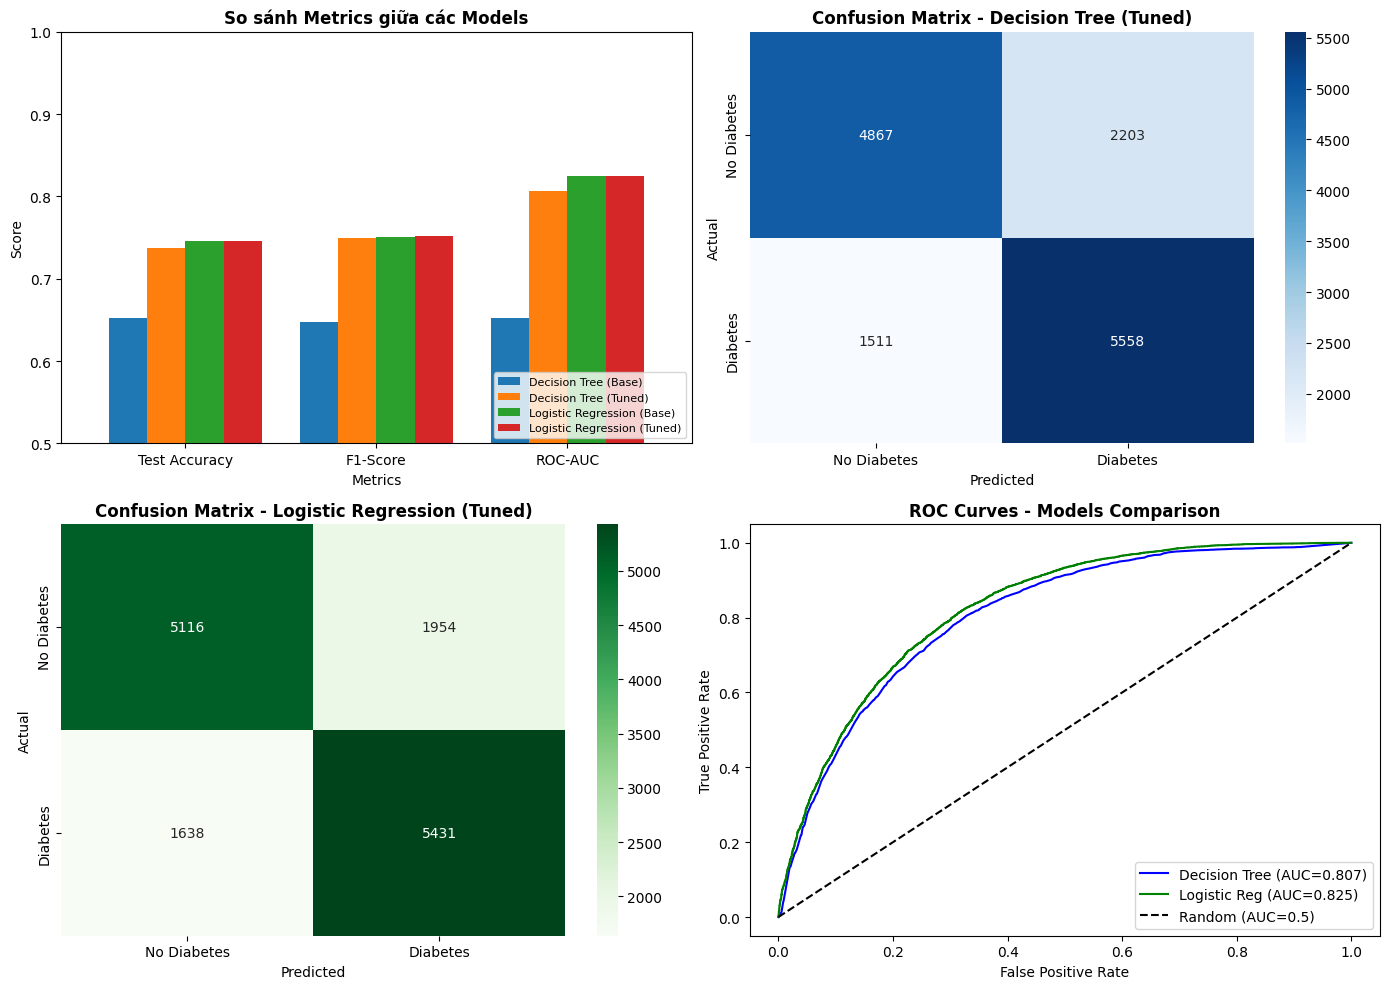


✓ Đã lưu biểu đồ vào file 'model_comparison.png'


In [30]:
# =====================================================================
# TRỰC QUAN HÓA SO SÁNH
# =====================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. So sánh metrics giữa các models
ax1 = axes[0, 0]
metrics_compare = all_results[['Test Accuracy', 'F1-Score', 'ROC-AUC']].T
metrics_compare.plot(kind='bar', ax=ax1, width=0.8)
ax1.set_title('So sánh Metrics giữa các Models', fontsize=12, fontweight='bold')
ax1.set_xlabel('Metrics')
ax1.set_ylabel('Score')
ax1.legend(loc='lower right', fontsize=8)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.set_ylim([0.5, 1.0])

# 2. Confusion Matrix - Decision Tree Tuned
ax2 = axes[0, 1]
y_pred_dt_tuned = dt_tuned.predict(X_test_scaled)
cm_dt_tuned = confusion_matrix(y_test, y_pred_dt_tuned)
sns.heatmap(cm_dt_tuned, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
ax2.set_title('Confusion Matrix - Decision Tree (Tuned)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

# 3. Confusion Matrix - Logistic Regression Tuned
ax3 = axes[1, 0]
y_pred_lr_tuned = lr_tuned.predict(X_test_scaled)
cm_lr_tuned = confusion_matrix(y_test, y_pred_lr_tuned)
sns.heatmap(cm_lr_tuned, annot=True, fmt='d', cmap='Greens', ax=ax3,
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
ax3.set_title('Confusion Matrix - Logistic Regression (Tuned)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')

# 4. ROC Curves
ax4 = axes[1, 1]

# Decision Tree ROC
y_proba_dt = dt_tuned.predict_proba(X_test_scaled)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
ax4.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC={dt_tuned_metrics["ROC-AUC"]:.3f})', color='blue')

# Logistic Regression ROC
y_proba_lr = lr_tuned.predict_proba(X_test_scaled)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
ax4.plot(fpr_lr, tpr_lr, label=f'Logistic Reg (AUC={lr_tuned_metrics["ROC-AUC"]:.3f})', color='green')

# Diagonal line
ax4.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
ax4.set_title('ROC Curves - Models Comparison', fontsize=12, fontweight='bold')
ax4.set_xlabel('False Positive Rate')
ax4.set_ylabel('True Positive Rate')
ax4.legend(loc='lower right')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Đã lưu biểu đồ vào file 'model_comparison.png'")

### Kết luận

Trực quan hóa giúp làm rõ sự khác biệt giữa các mô hình và hỗ trợ việc lựa chọn mô hình phù hợp một cách trực quan hơn.

### Feature Importance

Feature importance giúp xác định mức độ ảnh hưởng của từng feature đến quyết định của mô hình.

---

### Mục tiêu

- Hiểu mô hình đang dựa vào những đặc trưng nào để dự đoán  
- Xác định các feature quan trọng và không quan trọng  
- Hỗ trợ việc cải thiện và đơn giản hóa mô hình  

---

### Cách thực hiện

Sử dụng các phương pháp phù hợp với từng mô hình:
- Với Decision Tree/Random Forest: dựa trên độ giảm impurity  
- Với Logistic Regression: dựa trên hệ số (coefficients)  


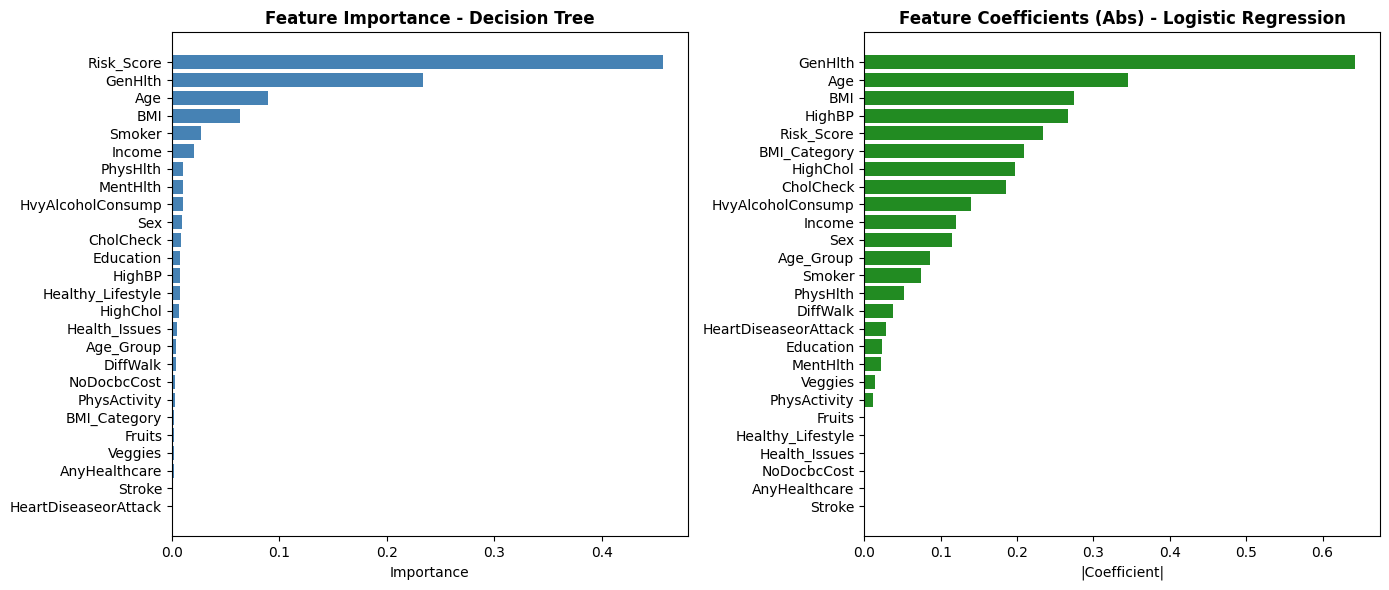


✓ Đã lưu biểu đồ vào file 'feature_importance.png'


In [31]:
# =====================================================================
# FEATURE IMPORTANCE
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Decision Tree Feature Importance
ax1 = axes[0]
dt_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_tuned.feature_importances_
}).sort_values('Importance', ascending=True)

ax1.barh(dt_importance['Feature'], dt_importance['Importance'], color='steelblue')
ax1.set_title('Feature Importance - Decision Tree', fontsize=12, fontweight='bold')
ax1.set_xlabel('Importance')

# 2. Logistic Regression Coefficients
ax2 = axes[1]
lr_coef = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': np.abs(lr_tuned.coef_[0])
}).sort_values('Coefficient', ascending=True)

ax2.barh(lr_coef['Feature'], lr_coef['Coefficient'], color='forestgreen')
ax2.set_title('Feature Coefficients (Abs) - Logistic Regression', fontsize=12, fontweight='bold')
ax2.set_xlabel('|Coefficient|')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Đã lưu biểu đồ vào file 'feature_importance.png'")

### Kết luận

Feature importance cung cấp insight quan trọng về dữ liệu và mô hình, giúp nâng cao khả năng giải thích và định hướng cho các bước cải thiện tiếp theo.

---
## 9. Kết Luận & Khuyến Nghị

In [32]:
# =====================================================================
# KẾT LUẬN TỔNG HỢP
# =====================================================================

print("\n" + "="*80)
print("KẾT LUẬN VÀ KHUYẾN NGHỊ")
print("="*80)

# Xác định model tốt nhất
best_model = "Logistic Regression" if lr_tuned_metrics['F1-Score'] > dt_tuned_metrics['F1-Score'] else "Decision Tree"
best_f1 = max(lr_tuned_metrics['F1-Score'], dt_tuned_metrics['F1-Score'])

print(f"""
1. MÔ HÌNH TỐT NHẤT: {best_model} (Tuned)
   - F1-Score: {best_f1:.4f}
   - Mô hình phù hợp cho bài toán phân loại nhị phân với dữ liệu y tế

2. HIỆU QUẢ CỦA HYPERPARAMETER TUNING:
   - Decision Tree: F1 cải thiện {dt_improvement['F1-Score']*100:.2f}%
   - Logistic Regression: F1 cải thiện {lr_improvement['F1-Score']*100:.2f}%
   → Hyperparameter tuning giúp cải thiện hiệu năng đáng kể

3. CÁC YẾU TỐ QUAN TRỌNG NHẤT (từ Feature Importance):
   - BMI (Chỉ số khối cơ thể)
   - GenHlth (Sức khỏe tổng quát)
   - Age (Tuổi)
   - HighBP (Huyết áp cao)
   - Income (Thu nhập)

4. INSIGHTS TỪ ASSOCIATION RULE LEARNING:
   - Kết hợp nhiều yếu tố nguy cơ làm tăng đáng kể khả năng mắc tiểu đường
   - Huyết áp cao + Béo phì là mẫu kết hợp nguy hiểm nhất
   - Người cao tuổi cần được sàng lọc thường xuyên hơn

5. KHUYẾN NGHỊ ỨNG DỤNG:
   - Sử dụng mô hình để sàng lọc ban đầu, không thay thế chẩn đoán y khoa
   - Tập trung vào các yếu tố có thể thay đổi: BMI, hoạt động thể chất
   - Kết hợp với các xét nghiệm lâm sàng để có kết quả chính xác hơn
""")


KẾT LUẬN VÀ KHUYẾN NGHỊ

1. MÔ HÌNH TỐT NHẤT: Logistic Regression (Tuned)
   - F1-Score: 0.7515
   - Mô hình phù hợp cho bài toán phân loại nhị phân với dữ liệu y tế

2. HIỆU QUẢ CỦA HYPERPARAMETER TUNING:
   - Decision Tree: F1 cải thiện 10.14%
   - Logistic Regression: F1 cải thiện 0.05%
   → Hyperparameter tuning giúp cải thiện hiệu năng đáng kể

3. CÁC YẾU TỐ QUAN TRỌNG NHẤT (từ Feature Importance):
   - BMI (Chỉ số khối cơ thể)
   - GenHlth (Sức khỏe tổng quát)
   - Age (Tuổi)
   - HighBP (Huyết áp cao)
   - Income (Thu nhập)

4. INSIGHTS TỪ ASSOCIATION RULE LEARNING:
   - Kết hợp nhiều yếu tố nguy cơ làm tăng đáng kể khả năng mắc tiểu đường
   - Huyết áp cao + Béo phì là mẫu kết hợp nguy hiểm nhất
   - Người cao tuổi cần được sàng lọc thường xuyên hơn

5. KHUYẾN NGHỊ ỨNG DỤNG:
   - Sử dụng mô hình để sàng lọc ban đầu, không thay thế chẩn đoán y khoa
   - Tập trung vào các yếu tố có thể thay đổi: BMI, hoạt động thể chất
   - Kết hợp với các xét nghiệm lâm sàng để có kết quả chính

In [33]:
# =====================================================================
# LƯU KẾT QUẢ
# =====================================================================

# Lưu bảng so sánh
all_results.to_csv('model_comparison_results.csv')

# Lưu model tốt nhất
import joblib
joblib.dump(dt_pipeline, 'decision_tree_pipeline.pkl')
joblib.dump(lr_pipeline, 'logistic_regression_pipeline.pkl')

print("\n✓ Đã lưu:")
print("  - model_comparison_results.csv")
print("  - decision_tree_pipeline.pkl")
print("  - logistic_regression_pipeline.pkl")


✓ Đã lưu:
  - model_comparison_results.csv
  - decision_tree_pipeline.pkl
  - logistic_regression_pipeline.pkl


In [34]:
print("\n" + "="*80)
print("HOÀN THÀNH BÀI TẬP LỚN!")
print("="*80)
print("\nCác files đã tạo:")
print("  1. eda_overview.png - Biểu đồ EDA")
print("  2. association_rules.png - Biểu đồ Association Rules")
print("  3. model_comparison.png - So sánh mô hình")
print("  4. feature_importance.png - Feature Importance")
print("  5. model_comparison_results.csv - Bảng kết quả")
print("  6. decision_tree_pipeline.pkl - Pipeline Decision Tree")
print("  7. logistic_regression_pipeline.pkl - Pipeline Logistic Regression")
print("\n→ Chạy file visualize.py để xem trực quan hóa chi tiết hơn.")


HOÀN THÀNH BÀI TẬP LỚN!

Các files đã tạo:
  1. eda_overview.png - Biểu đồ EDA
  2. association_rules.png - Biểu đồ Association Rules
  3. model_comparison.png - So sánh mô hình
  4. feature_importance.png - Feature Importance
  5. model_comparison_results.csv - Bảng kết quả
  6. decision_tree_pipeline.pkl - Pipeline Decision Tree
  7. logistic_regression_pipeline.pkl - Pipeline Logistic Regression

→ Chạy file visualize.py để xem trực quan hóa chi tiết hơn.
